In [5]:
!pip install -q datasets


In [6]:
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from tensorflow.keras.utils import to_categorical

print("Downloading dataset from Hugging Face...")
# Load the official GTSRB benchmark
dataset = load_dataset("tanganke/GTSRB")

NUM_CLASSES = 43
IMG_SIZE = 32

def prepare_data(hf_split):
    images = []
    labels = []
    for item in hf_split:
        img = item['image'].convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        images.append(np.array(img, dtype='float32') / 255.0)
        labels.append(item['label'])
    return np.array(images), to_categorical(np.array(labels), num_classes=NUM_CLASSES)

print("Preparing training images...")
X_train, y_train = prepare_data(dataset['train'])

print("Preparing test images...")
X_test, y_test = prepare_data(dataset['test'])

print(f"Done! Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

README.md:   0%|          | 0.00/8.52k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  224MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  109MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating jpeg_compression split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/12630 [00:00<?, ? examples/s]

Preparing training images...
Preparing test images...
Done! Train samples: 26640, Test samples: 12630


In [7]:
from tensorflow.keras import layers, models

# 1. Define the CNN architecture
model = models.Sequential([
    # Feature Extractor 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Feature Extractor 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 2. Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train on GPU (10 epochs)
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_test, y_test)
)

# 4. Final Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

# 5. Save model
model.save("traffic_sign_classifier.keras")
print("Model saved successfully as 'traffic_sign_classifier.keras'")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5467 - loss: 1.5939 - val_accuracy: 0.8806 - val_loss: 0.4609
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9029 - loss: 0.3161 - val_accuracy: 0.9296 - val_loss: 0.2892
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9492 - loss: 0.1694 - val_accuracy: 0.9465 - val_loss: 0.2205
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9639 - loss: 0.1151 - val_accuracy: 0.9576 - val_loss: 0.2076
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9720 - loss: 0.0903 - val_accuracy: 0.9606 - val_loss: 0.1936
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9792 - loss: 0.0682 - val_accuracy: 0.9593 - val_loss: 0.1752
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9801 - loss: 0.0625 - val_accuracy: 0.9637 - val_loss: 0.1746
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9827 - loss: 0.0533 - val_accuracy: 

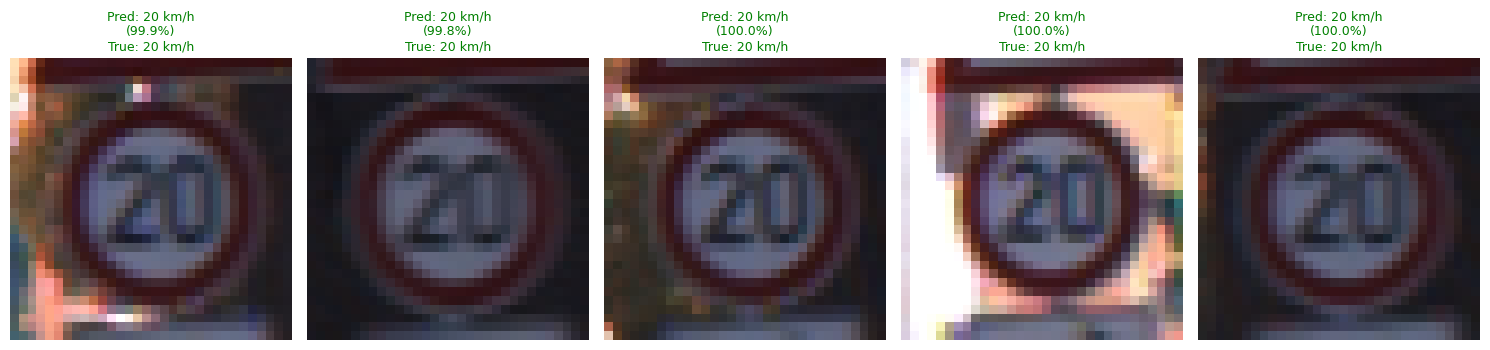

In [8]:
import matplotlib.pyplot as plt

# Label dictionary for all 43 GTSRB classes
class_names = {
    0: '20 km/h', 1: '30 km/h', 2: '50 km/h', 3: '60 km/h', 4: '70 km/h',
    5: '80 km/h', 6: 'End of 80 km/h', 7: '100 km/h', 8: '120 km/h', 9: 'No passing',
    10: 'No passing > 3.5t', 11: 'Right-of-way next int.', 12: 'Priority road',
    13: 'Yield', 14: 'Stop', 15: 'No vehicles', 16: 'Vehicles > 3.5t prohibited',
    17: 'No entry', 18: 'General caution', 19: 'Dangerous curve left',
    20: 'Dangerous curve right', 21: 'Double curve', 22: 'Bumpy road',
    23: 'Slippery road', 24: 'Road narrows right', 25: 'Road work',
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End all speed/pass limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End of no passing > 3.5t'
}

# Predict on a batch of 5 test samples
plt.figure(figsize=(15, 4))
for i in range(5):
    img = X_test[i]
    true_id = np.argmax(y_test[i])

    # Model inference
    preds = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_id = int(np.argmax(preds))
    confidence = float(np.max(preds)) * 100

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    color = 'green' if pred_id == true_id else 'red'
    plt.title(f"Pred: {class_names[pred_id]}\n({confidence:.1f}%)\nTrue: {class_names[true_id]}",
              fontsize=9, color=color)

plt.tight_layout()
plt.show()

Please upload a traffic sign image (.jpg or .png):


Saving stop.jpeg to stop.jpeg


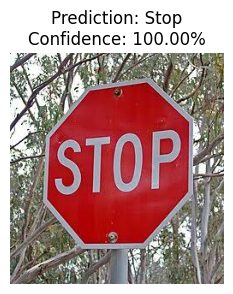

In [9]:
from google.colab import files
from PIL import Image

print("Please upload a traffic sign image (.jpg or .png):")
uploaded = files.upload()

for filename in uploaded.keys():
    # Load and preprocess uploaded image
    img = Image.open(filename).convert('RGB')
    img_resized = img.resize((32, 32))
    img_array = np.array(img_resized, dtype='float32') / 255.0
    input_data = np.expand_dims(img_array, axis=0)

    # Predict
    preds = model.predict(input_data, verbose=0)
    pred_id = int(np.argmax(preds))
    confidence = float(np.max(preds)) * 100

    # Display image & result
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {class_names.get(pred_id, 'Unknown')}\nConfidence: {confidence:.2f}%")
    plt.show()

In [10]:
from google.colab import files
files.download("traffic_sign_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

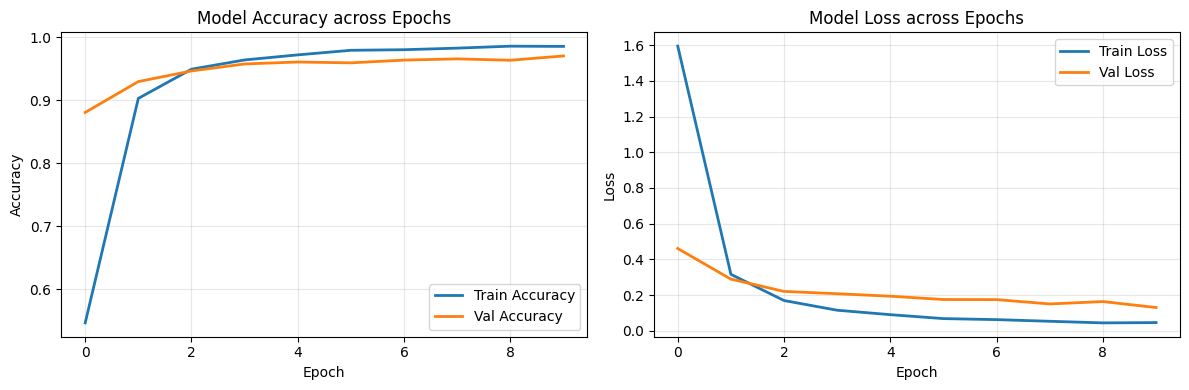

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', lw=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', lw=2)
plt.title('Model Accuracy across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
!pip install -q gradio

import gradio as gr
import numpy as np
from PIL import Image

def classify_traffic_sign(input_image):
    # Resize and normalize
    img = Image.fromarray(input_image).convert('RGB').resize((32, 32))
    img_array = np.array(img, dtype='float32') / 255.0
    input_tensor = np.expand_dims(img_array, axis=0)

    # Predict
    preds = model.predict(input_tensor, verbose=0)[0]

    # Return dictionary of top-3 probabilities
    top_indices = np.argsort(preds)[::-1][:3]
    return {class_names[idx]: float(preds[idx]) for idx in top_indices}

demo = gr.Interface(
    fn=classify_traffic_sign,
    inputs=gr.Image(type="numpy", label="Upload Road Sign"),
    outputs=gr.Label(num_top_classes=3, label="Predictions"),
    title="Traffic Sign Recognition AI",
    description="Upload any photo of a road sign to see real-time classification."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fcfa9cd718ac8a6ed2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
